# LAB | Feature Engineering

**Load the data**

In this challenge, we will be working with the same Spaceship Titanic data, like the previous Lab. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In [65]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [66]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


**Check the shape of your data**

In [67]:
spaceship.shape

(8693, 14)

In [68]:
spaceship.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


**Check for data types**

In [69]:
spaceship.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

In [70]:
spaceship.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

**Check for missing values**

In [71]:
nulos=spaceship.isnull().sum()
print(nulos[nulos>0]if nulos.any()else 'No hay nulos')

HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
dtype: int64


There are multiple strategies to handle missing data

- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

For this exercise, because we have such low amount of null values, we will drop rows containing any missing value. 

In [72]:
df=spaceship.dropna()

Revisamos que no tengamos nulos en el data frame

In [73]:
df.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6606 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   6606 non-null   object 
 1   HomePlanet    6606 non-null   object 
 2   CryoSleep     6606 non-null   object 
 3   Cabin         6606 non-null   object 
 4   Destination   6606 non-null   object 
 5   Age           6606 non-null   float64
 6   VIP           6606 non-null   object 
 7   RoomService   6606 non-null   float64
 8   FoodCourt     6606 non-null   float64
 9   ShoppingMall  6606 non-null   float64
 10  Spa           6606 non-null   float64
 11  VRDeck        6606 non-null   float64
 12  Name          6606 non-null   object 
 13  Transported   6606 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 729.0+ KB


- **Cabin** is too granular - transform it in order to obtain {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'}

In [75]:
# Convertimos a string y extraemos la letra de la cubierta (Deck)
# Usamos .str[0] para obtener el primer carácter de la cadena
df['Cabin'] = df['Cabin'].fillna('Unknown').astype(str).str[0]

C:\Users\tachi\AppData\Local\Temp\ipykernel_19416\286053115.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cabin'] = df['Cabin'].fillna('Unknown').astype(str).str[0]


In [76]:
# Si quieres asegurar que solo queden las letras del set {'A', 'B', ...}
# y manejar valores que no coincidan como 'U' (Unknown)
valid_decks = {'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'}
df['Cabin'] = df['Cabin'].apply(lambda x: x if x in valid_decks else 'Unknown')

# Visualizamos el resultado
df[['PassengerId', 'Cabin']].head()

C:\Users\tachi\AppData\Local\Temp\ipykernel_19416\2867306394.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Cabin'] = df['Cabin'].apply(lambda x: x if x in valid_decks else 'Unknown')


,PassengerId,Cabin
0,0001_01,B
1,0002_01,F
2,0003_01,A
3,0003_02,A
4,0004_01,F


- Drop PassengerId and Name

In [77]:
df.drop(['PassengerId', 'Name'], axis=1, inplace=True)

C:\Users\tachi\AppData\Local\Temp\ipykernel_19416\4183486857.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['PassengerId', 'Name'], axis=1, inplace=True)


In [78]:
df.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,B,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,F,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,A,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,A,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,F,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


- For non-numerical columns, do dummies.

In [79]:
mapa = {False: 0, True: 1}
df['VIP'] = df['VIP'].map(mapa)
df["CryoSleep"] = df["CryoSleep"].map(mapa)
df["Transported"] = df["Transported"].map(mapa)
df.head()

C:\Users\tachi\AppData\Local\Temp\ipykernel_19416\709519558.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['VIP'] = df['VIP'].map(mapa)
C:\Users\tachi\AppData\Local\Temp\ipykernel_19416\709519558.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["CryoSleep"] = df["CryoSleep"].map(mapa)
C:\Users\tachi\AppData\Local\Temp\ipykernel_19416\709519558.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,0,B,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,0
1,Earth,0,F,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,1
2,Europa,0,A,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0
3,Europa,0,A,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0
4,Earth,0,F,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,1


In [80]:
df = pd.get_dummies(df, columns=['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP'], drop_first=False)

In [81]:
df.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,...,Cabin_D,Cabin_E,Cabin_F,Cabin_G,Cabin_T,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_0,VIP_1
0,39.0,0.0,0.0,0.0,0.0,0.0,0,False,True,False,...,False,False,False,False,False,False,False,True,True,False
1,24.0,109.0,9.0,25.0,549.0,44.0,1,True,False,False,...,False,False,True,False,False,False,False,True,True,False
2,58.0,43.0,3576.0,0.0,6715.0,49.0,0,False,True,False,...,False,False,False,False,False,False,False,True,False,True
3,33.0,0.0,1283.0,371.0,3329.0,193.0,0,False,True,False,...,False,False,False,False,False,False,False,True,True,False
4,16.0,303.0,70.0,151.0,565.0,2.0,1,True,False,False,...,False,False,True,False,False,False,False,True,True,False


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6606 entries, 0 to 8692
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6606 non-null   float64
 1   RoomService                6606 non-null   float64
 2   FoodCourt                  6606 non-null   float64
 3   ShoppingMall               6606 non-null   float64
 4   Spa                        6606 non-null   float64
 5   VRDeck                     6606 non-null   float64
 6   Transported                6606 non-null   int64  
 7   HomePlanet_Earth           6606 non-null   bool   
 8   HomePlanet_Europa          6606 non-null   bool   
 9   HomePlanet_Mars            6606 non-null   bool   
 10  CryoSleep_0                6606 non-null   bool   
 11  CryoSleep_1                6606 non-null   bool   
 12  Cabin_A                    6606 non-null   bool   
 13  Cabin_B                    6606 non-null   bool   
 1

Veamos la muestra

In [83]:
df1=df[df["Transported"] == 0] #false
df2=df[df["Transported"] == 1] #true

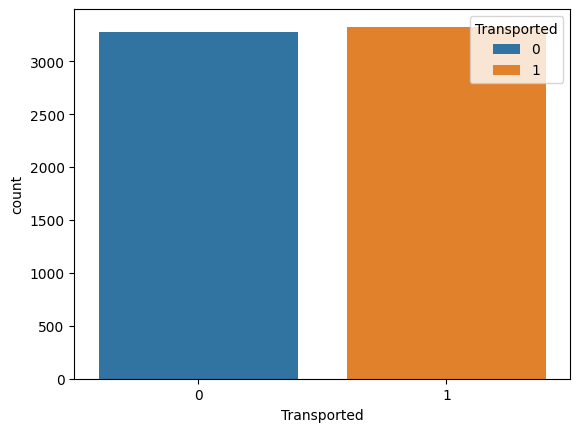

In [84]:
sns.countplot(df, x="Transported",hue= "Transported")
plt.show()

**Perform Train Test Split**

In [86]:
X = df.drop('Transported', axis=1)
y = df['Transported']

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de entrenamiento: {X_train.shape[0]} muestras")
print(f"Set de prueba: {X_test.shape[0]} muestras")

Set de entrenamiento: 5284 muestras
Set de prueba: 1322 muestras


**Model Selection**

In this exercise we will be using **KNN** as our predictive model.

In [88]:
# 1. Instanciar el modelo
# Elegimos n_neighbors=5 como valor estándar inicial
knn = KNeighborsClassifier(n_neighbors=5)

# 2. Entrenar el modelo con el set de entrenamiento
knn.fit(X_train, y_train)

# 3. Realizar predicciones en el set de prueba
y_pred = knn.predict(X_test)

# 4. Evaluar el rendimiento
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo KNN: {accuracy:.4f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))


Precisión del modelo KNN: 0.7844

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       653
           1       0.79      0.78      0.79       669

    accuracy                           0.78      1322
   macro avg       0.78      0.78      0.78      1322
weighted avg       0.78      0.78      0.78      1322



- Evaluate your model's performance. Comment it

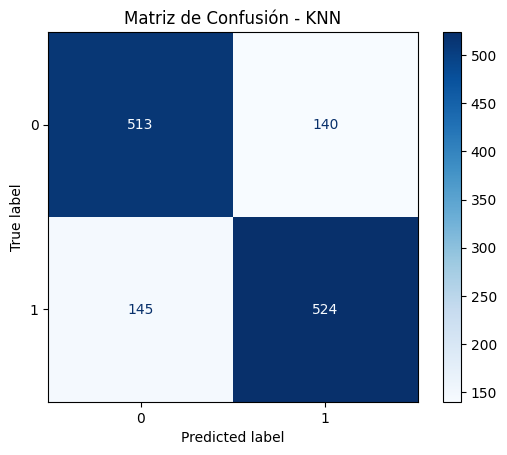

Accuracy Score: 0.7844


In [89]:
# 1. Matriz de Confusión para ver dónde se equivoca el modelo
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)

# Graficar
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - KNN")
plt.show()

# 2. Resumen de métricas
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")


#Estandarización

In [90]:
# 1. Inicializar el escalador
scaler = StandardScaler()

# 2. Ajustar y transformar los datos de entrenamiento
# El escalador aprende la media y desviación estándar de X_train
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transformar los datos de prueba usando los parámetros aprendidos de X_train
X_test_scaled = scaler.transform(X_test)

# 4. Re-entrenar el modelo KNN con los datos escalados
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

# 5. Predecir y evaluar
y_pred_scaled = knn_scaled.predict(X_test_scaled)
new_accuracy = accuracy_score(y_test, y_pred_scaled)

print(f"Precisión antes del escalado: {accuracy:.4f}")
print(f"Precisión después del escalado: {new_accuracy:.4f}")
print("\nNuevo Informe de Clasificación:")
print(classification_report(y_test, y_pred_scaled))


Precisión antes del escalado: 0.7844
Precisión después del escalado: 0.7829

Nuevo Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       653
           1       0.79      0.78      0.78       669

    accuracy                           0.78      1322
   macro avg       0.78      0.78      0.78      1322
weighted avg       0.78      0.78      0.78      1322

